# 2D Implmentation of the Helmoltz solver

2D Helmholtz Equation: Finite Difference Derivation and Spectral Decomposition

The 2D Helmholtz equation is:

$$
\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} + k^2 u = f(x, y)
$$

Discretization
* Domain: Split into an $ N \times M $ grid with spacing $ h = \frac{1}{N+1} $ in $ x $ and $ y $.
* Let $ u_{i,j} \approx u(x_i, y_j) $ and $ f_{i,j} = f(x_i, y_j) $, where $ x_i = ih $ and $ y_j = jh $.


Central Difference Approximation
The second derivatives are approximated as:

$$
\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i-1,j} - 2u_{i,j} + u_{i+1,j}}{h^2}, \quad \frac{\partial^2 u}{\partial y^2} \approx \frac{u_{i,j-1} - 2u_{i,j} + u_{i,j+1}}{h^2}
$$

Substituting into the Helmholtz Equation
$$
\frac{u_{i-1,j} + u_{i+1,j} + u_{i,j-1} + u_{i,j+1} - 4u_{i,j}}{h^2} + k^2 u_{i,j} = f_{i,j}
$$

Rearranging gives the linear equation for interior points:

$$
\frac{1}{h^2}u_{i-1,j} + \frac{1}{h^2}u_{i+1,j} + \frac{1}{h^2}u_{i,j-1} + \frac{1}{h^2}u_{i,j+1} + \left(\frac{-4}{h^2} + k^2\right)u_{i,j} = f_{i,j}
$$

Spectral Decomposition in the $ y $-Direction
To preserve the tridiagonal structure, decompose the problem using the Discrete Sine Transform (DST)} for Dirichlet BCs (or DCT for Neumann BCs):

Forward DST on $ f(x, y) $
* For each column $ x_i $, compute the spectral coefficients:
$$
\tilde{f}_{i,m} = \text{DST}\left[f_{i,j}\right] = \sum_{j=1}^{N_y-1} f_{i,j} \sin\left(\frac{m \pi j}{N_y}\right)
$$
This diagonalizes the $ y $-Laplacian into eigenvalues $ \lambda_m^{(y)} = -\frac{4}{h^2} \sin^2\left(\frac{m \pi h}{2L_y}\right) $.

Modified 1D Helmholtz Equations in $ x $:

For each mode $ m $, solve:
$$
\frac{d^2 \tilde{u}_m}{dx^2} + \left(k^2 - \lambda_m^{(y)}\right)\tilde{u}_m = \tilde{f}_m(x)
$$
*This is a tridiagonal system} identical to the 1D case, with effective wavenumber $ k_{\text{eff}}^2 = k^2 - \lambda_m^{(y)} $.

Matrix Form for Each Mode}

*For each $ m $, the tridiagonal matrix $ A_m $ has:

* Diagonal entries: $ \frac{-2}{h^2} + k_{\text{eff}}^2 $
* Off-diagonal entries: $ \frac{1}{h^2} $
* Solve $ A_m \tilde{u}_m = \tilde{f}_m $ using your 1D solver.

Inverse DST to Reconstruct $ u(x, y) $}

*For each column $ x_i $, compute:
$$
u_{i,j} = \text{Inverse DST}\left[\tilde{u}_{i,m}\right] = \frac{2}{N_y+1} \sum_{m=1}^{N_y-1} \tilde{u}_{i,m} \sin\left(\frac{m \pi j}{N_y}\right)
$$

Matrix Structure Summary

* Original 2D System: Block tridiagonal (not directly solvable with a 1D tridiagonal solver).
* After Spectral Decomposition}: Independent 1D tridiagonal systems for each mode $ m $.
* Key Advantage: Retains the efficiency of your 1D code by reducing the 2D problem to $ M $ 1D solves.




Import the necessary modules

In [49]:
# make use of QLS jupyter env
import numpy as np
import scipy as sc
from linear_solvers import NumPyLinearSolver, HHL
from linear_solvers.matrices.tridiagonal_toeplitz import TridiagonalToeplitz
from linear_solvers.matrices.numpy_matrix import NumPyMatrix
from qiskit.utils import QuantumInstance
from numerical_solvers.thomas_algorithm import numerical_solvers
from qiskit.quantum_info import Statevector
from qiskit import Aer, transpile
from scipy.sparse import diags
from scipy.fft import dst, idst
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.simplefilter('ignore')

Define the Utility functions which we will need:

In [55]:
from math import log2


def normalize(arr, t_min, t_max):
    """
    Normalize an array to a specified range [t_min, t_max].
    
    For data that spans both negative and positive values, this function
    uses a symmetric normalization (dividing by the maximum absolute value)
    to preserve the zero-crossing and the relative oscillatory behavior.
    
    For data that does not span both signs, it uses standard min-max normalization.
    """
    arr = np.array(arr)
    # Check if data spans both negative and positive values
    # Use symmetric normalization:
    max_abs = np.max(np.abs(arr))
    # Avoid division by zero
    if max_abs < 1e-12:
        norm_arr = arr.copy()
    else:
        norm_arr = arr / max_abs
    # If the target range is symmetric about zero (e.g., [-1, 1]),
    # then simply scale by the maximum absolute value.
    # Otherwise, map [-1, 1] to [t_min, t_max]:
    if t_min == -1 and t_max == 1:
        return norm_arr
    else:
        # Mapping from [-1,1] to [t_min, t_max]:
        return ((norm_arr + 1) / 2) * (t_max - t_min) + t_min
        
def get_solution_vector(solution, N, vector):
    """Extracts and normalizes simulated state vector from LinearSolverResult."""
    start = 2**(N-1)
    fin = 2**(N-1) + len(vector)
    solution_vector = Statevector(solution.state).data[start:fin].real
    norm = solution.euclidean_norm
    return norm*solution_vector / np.linalg.norm(solution_vector)

def construct_TT_matrix(main_diag, off_diag, size):
    '''
    Construct a tridiagonal Toeplitz matrix using the main diagonal and off-diagonal elements.
    '''
    matrix = diags([off_diag, main_diag, off_diag], offsets=[-1, 0, 1], shape=(size, size)).toarray()
    return matrix

def solve_1DHHL(matrix, vector, qubits, epsilon=0.01):
    '''
    Solves the 1D HHL
    '''
    a = matrix[0, 0]
    b = matrix[0, 1]
    
    tridi_mat = TridiagonalToeplitz(qubits, a, b)
    backend = Aer.get_backend('qasm_simulator')
    quantum_instance = QuantumInstance(backend, shots=1000)

    # 6) Solve unpreconditioned system with HHL
    tridi_hhl = HHL(epsilon=epsilon, quantum_instance=quantum_instance)
    hhl_solution_obj = tridi_hhl.solve(tridi_mat, vector)
    hhl_interior = get_solution_vector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, vector)
    #hhl_vector = np.concatenate(([0], hhl_interior, [0]))
    #hhl_sol = normalize(hhl_vector, -1.0, 1.0)
    return hhl_interior

def solve_1DThomas(matrix, vector):
    '''
    Solves the 1D Thomas algorithm
    '''
    
    # Compare to thomas
    thomas = numerical_solvers()
    num_solution = thomas.solve_tridiagonal_thomas(matrix, vector)
    #num_solution = np.concatenate(([0], num_solution, [0]))
    #num_solution = normalize(num_solution, -1.0, 1.0)
    return num_solution
   
def generate_forcing_function(Nx, Ny, Lx, Ly, forcing_type='uniform', **kwargs):
    """
    Generates a forcing function (RHS) for the 2D Helmholtz equation.
    
    Parameters:
        Nx, Ny : int
            Number of interior grid points in the x and y directions.
        Lx, Ly : float
            Domain lengths in x and y.
        forcing_type : str
            Type of forcing function to generate:
            - 'uniform': Constant value across domain
            - 'point_source': Point source at specified location
            - 'gaussian': Gaussian source
            - 'sinusoidal': Sinusoidal pattern
            - 'manufactured': Manufactured solution (for verification)
            - 'custom': Custom function provided as lambda
        **kwargs : dict
            Additional parameters for specific forcing types:
            - 'uniform': value (default=1.0)
            - 'point_source': x0, y0 (position), amplitude (default=1.0)
            - 'gaussian': x0, y0 (center), sigma (width), amplitude (default=1.0)
            - 'sinusoidal': kx, ky (wave numbers), amplitude (default=1.0)
            - 'manufactured': k (wave number from Helmholtz operator)
            - 'custom': func (lambda function taking x, y arrays)
    
    Returns:
        f : numpy.ndarray
            The forcing function as a flattened array of shape (Nx*Ny,).
        f_grid : numpy.ndarray
            The forcing function as a 2D grid of shape (Ny, Nx).
        x_grid, y_grid : numpy.ndarray
            Meshgrid of x and y coordinates.
    """
    # Compute grid spacings and coordinates
    hx = Lx / (Nx + 1)
    hy = Ly / (Ny + 1)
    
    # Create interior grid points
    x = np.linspace(hx, Lx - hx, Nx)
    y = np.linspace(hy, Ly - hy, Ny)
    x_grid, y_grid = np.meshgrid(x, y)
    
    # Initialize forcing function grid
    f_grid = np.zeros((Ny, Nx))
    
    # Generate forcing function based on type
    if forcing_type == 'uniform':
        value = kwargs.get('value', 1.0)
        f_grid = np.ones((Ny, Nx)) * value
        
    elif forcing_type == 'point_source':
        x0 = kwargs.get('x0', Lx/2)
        y0 = kwargs.get('y0', Ly/2)
        amplitude = kwargs.get('amplitude', 1.0)
        
        # Find closest grid point
        idx_x = np.argmin(np.abs(x - x0))
        idx_y = np.argmin(np.abs(y - y0))
        f_grid[idx_y, idx_x] = amplitude
        
    elif forcing_type == 'gaussian':
        x0 = kwargs.get('x0', Lx/2)
        y0 = kwargs.get('y0', Ly/2)
        sigma = kwargs.get('sigma', min(Lx, Ly)/8)
        amplitude = kwargs.get('amplitude', 1.0)
        
        f_grid = amplitude * np.exp(-((x_grid - x0)**2 + (y_grid - y0)**2) / (2 * sigma**2))
        
    elif forcing_type == 'sinusoidal':
        kx = kwargs.get('kx', np.pi/Lx)
        ky = kwargs.get('ky', np.pi/Ly)
        amplitude = kwargs.get('amplitude', 1.0)
        
        f_grid = amplitude * np.sin(kx * x_grid) * np.sin(ky * y_grid)
        
    elif forcing_type == 'manufactured':
        # For method of manufactured solutions, we choose a known solution u
        # and compute f = -∇²u - k²u
        k = kwargs.get('k', 1.0)
        
        # Define a known analytic solution that satisfies boundary conditions
        u_exact = np.sin(np.pi * x_grid / Lx) * np.sin(np.pi * y_grid / Ly)
        
        # Compute second derivatives for the Laplacian
        d2u_dx2 = -(np.pi/Lx)**2 * u_exact
        d2u_dy2 = -(np.pi/Ly)**2 * u_exact
        
        # Compute f = -∇²u - k²u
        f_grid = -(d2u_dx2 + d2u_dy2) - k**2 * u_exact
        
    elif forcing_type == 'custom':
        func = kwargs.get('func', lambda x, y: np.zeros_like(x))
        f_grid = func(x_grid, y_grid)
    
    else:
        raise ValueError(f"Unknown forcing_type: {forcing_type}")
    
    # Flatten the grid to match the format expected by the solver
    f = f_grid.flatten()
    
    return f, f_grid, x_grid, y_grid

def plot_forcing_function(f_grid, x_grid, y_grid, title="Forcing Function"):
    """
    Plot the 2D forcing function.
    
    Parameters:
        f_grid : numpy.ndarray
            The forcing function as a 2D grid.
        x_grid, y_grid : numpy.ndarray
            Meshgrid of x and y coordinates.
        title : str
            Plot title.
    """
    plt.figure(figsize=(6, 4))
    
    # Surface plot
    ax1 = plt.subplot(121, projection='3d')
    surf = ax1.plot_surface(x_grid, y_grid, f_grid, cmap='viridis')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_zlabel('f(x,y)')
    ax1.set_title('3D View')
    
    # 2D heatmap
    ax2 = plt.subplot(122)
    im = ax2.pcolormesh(x_grid, y_grid, f_grid, cmap='viridis', shading='auto')
    plt.colorbar(im, ax=ax2)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_title('2D View')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def ADI(u, Ax, Ay, f_interior, method = 'q', max_iter = 5):
    N = u.shape[0]
    NUM_QUBITS = int(log2(N))
    iter = 0
    while iter < max_iter:
        print(f'Iteration: {iter}')
        # Now treat x as implicit and the y as explicit
        for j in range(N):
            # Extract the f for this row
            f_j = f_interior[j, :]
            
            # Absorb the top row and bottom row into the vector
            topu = u[j + 1, :] if j + 1 < N else np.zeros(N)
            bottomu = u[j - 1,:] if j - 1 >= 0 else np.zeros(N)
            
            f_j = f_j - topu - bottomu
            
            # Using the 1D method solve the system
            if method == 'q':
                solution = solve_1DHHL(Ax, f_j, NUM_QUBITS)
            else:
                solution = solve_1DThomas(Ax, f_j)
            
            # update the u
            u[j, :] = solution
        
        # Now treat x as implicit and the y as explicit
        for i in range(N):
            # Extract the f for this column
            f_i = f_interior[:, i]
            
            # Absorb the left column and right column into the vector
            leftu = u[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            rightu = u[:, i + 1] if i + 1 < N else np.zeros(N)
            
            f_i = f_i - leftu - rightu
            
            # Using the 1D method solve the system
            if method == 'q':
                solution = solve_1DHHL(Ay, f_i, NUM_QUBITS)
            else:
                solution = solve_1DThomas(Ay, f_i)
            
            # update the u
            u[:, i] = solution

        iter += 1
                  
    return u
        

## Solution Validation :: SINE
Define the Simulation parameters

In [102]:
# Domain specifications
Lx = 1.0       # Length of the x-dimension
Ly = 1.0       # Length of the y-dimension
NUM_QUBITS = 4 # Number of qubits used to represent the solution
N = 2**NUM_QUBITS  # Number of interior grid points in each dimension
N_total = N + 2    # Total grid points including boundaries

dx = Lx / (N + 1)  # Grid spacing (consistent with N interior points)
dy = Ly / (N + 1)
h = dx

# Create full grid including boundaries
x_vals = np.linspace(0, Lx, N_total)
y_vals = np.linspace(0, Ly, N_total)

# Extract interior points (excluding boundaries)
interior_x = x_vals[1:-1]
interior_y = y_vals[1:-1]
interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

# PDE specifications
k = 2.0  # Wave Number

# Evaluate forcing function only on the interior grid points
f_interior = -np.sin(np.pi * interior_X) * np.sin(np.pi * interior_Y)

# make a high resolution grid
X_high_res, Y_high_res = np.meshgrid(np.linspace(0, Lx, 100), np.linspace(0, Ly, 100), indexing='ij')
u_analytical = np.sin(np.pi * X_high_res) * np.sin(np.pi * Y_high_res) / (2 * np.pi**2 - k**2)

X_full, Y_full = np.meshgrid(x_vals, y_vals, indexing='ij')
u_analytical_resampled = np.sin(np.pi * X_full) * np.sin(np.pi * Y_full) / (2 * np.pi**2 - k**2)



Generate the Operator matrices

In [105]:
main_diag = -4/h**2 + k**2
off_diag = 1/h**2
Ax = construct_TT_matrix(main_diag=main_diag, off_diag=off_diag, size=N)
Ay = Ax

ADI method Loop

In [106]:
from mpl_toolkits.mplot3d import Axes3D

# Initialize solution to be all 0
u_init = np.zeros((N, N))

iter = 0
max_iter = 3
lb = -1.0
ub = 1.0
eps_tol = 0.1

# Generate grid
x, y = np.meshgrid(x_vals, y_vals, indexing='ij')

def ADI_val(u, Lx,Ly, Ax, Ay, f_interior, method = 'q', max_iter = 5):
    N = u.shape[0]
    
    x_vals = np.linspace(0, Lx, N+2)
    y_vals = np.linspace(0, Ly, N+2)
    X_full, Y_full = np.meshgrid(x_vals, y_vals, indexing='ij')
    
    errors = []
    u_analytical_resampled = np.sin(np.pi * X_full) * np.sin(np.pi * Y_full) / (2 * np.pi**2 - k**2)
    
    iter = 0
    while iter < max_iter:
        print(f'Iteration: {iter}')
        # Now treat x as implicit and the y as explicit
        for j in range(N):
            # Extract the f for this row
            f_j = f_interior[j, :]
            
            # Absorb the top row and bottom row into the vector
            topu = u[j + 1, :] if j + 1 < N else np.zeros(N)
            bottomu = u[j - 1,:] if j - 1 >= 0 else np.zeros(N)
            
            f_j = f_j - topu - bottomu
            
            # Using the 1D method solve the system
            if method == 'q':
                solution = solve_1DHHL(Ax, f_j, NUM_QUBITS)
            else:
                solution = solve_1DThomas(Ax, f_j)
            
            # update the u
            u[j, :] = solution
        
        # Now treat x as implicit and the y as explicit
        for i in range(N):
            # Extract the f for this column
            f_i = f_interior[:, i]
            
            # Absorb the left column and right column into the vector
            leftu = u[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            rightu = u[:, i + 1] if i + 1 < N else np.zeros(N)
            
            f_i = f_i - leftu - rightu
            
            # Using the 1D method solve the system
            if method == 'q':
                solution = solve_1DHHL(Ay, f_i, NUM_QUBITS)
            else:
                solution = solve_1DThomas(Ay, f_i)
            
            # update the u
            u[:, i] = solution

        
        # Calculate error by padding current solution and comparing to analytical
        u_padded = np.pad(u, pad_width=1, mode='constant', constant_values=0)
        #u_padded, u_analytical_resampled = normalize(u_padded, -1, 1) , normalize(u_analytical_resampled, -1, 1)
        error = np.linalg.norm(u_padded - u_analytical_resampled)
        errors.append(error)
        
        print(f"Error after iteration {iter+1}: {error}")
        
        iter += 1
                  
    return u, errors
        

# Solve using the ADI now in quantum
u_hhl, errors_hhl = ADI_val(u_init ,Lx, Ly, Ax, Ay, f_interior, method='q')

u_tom, errors_tom = ADI_val(u_init ,Lx, Ly, Ax, Ay, f_interior, method='num')


Iteration: 0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Num

Visuals

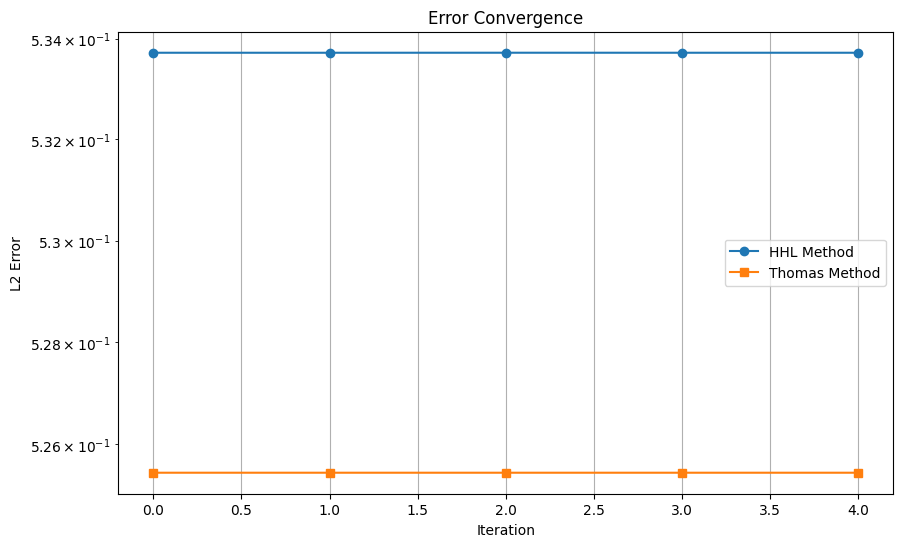

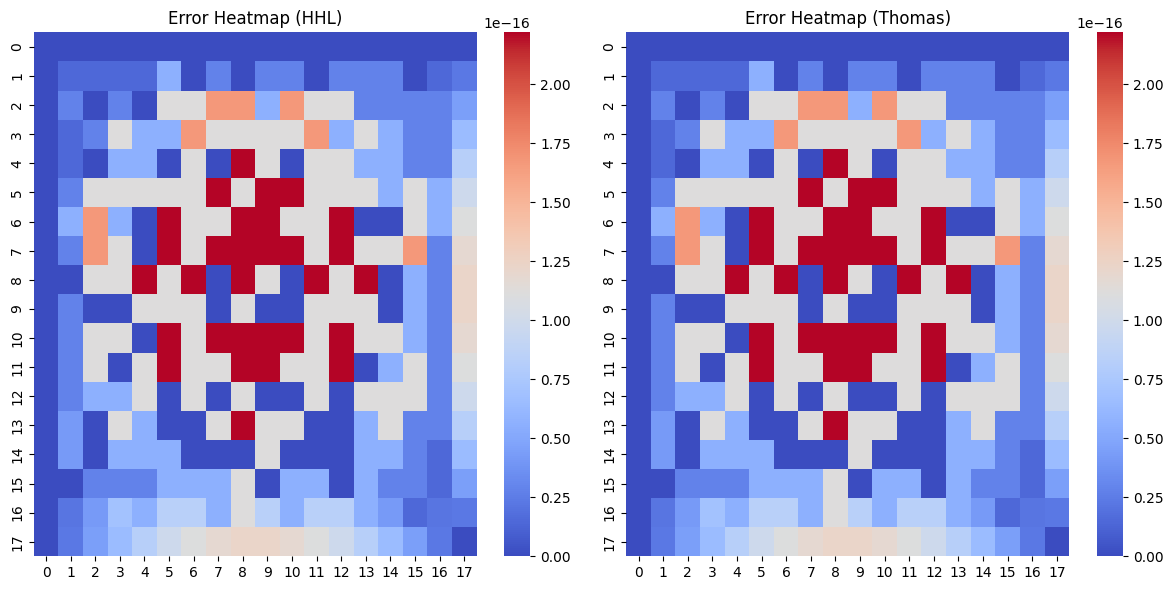

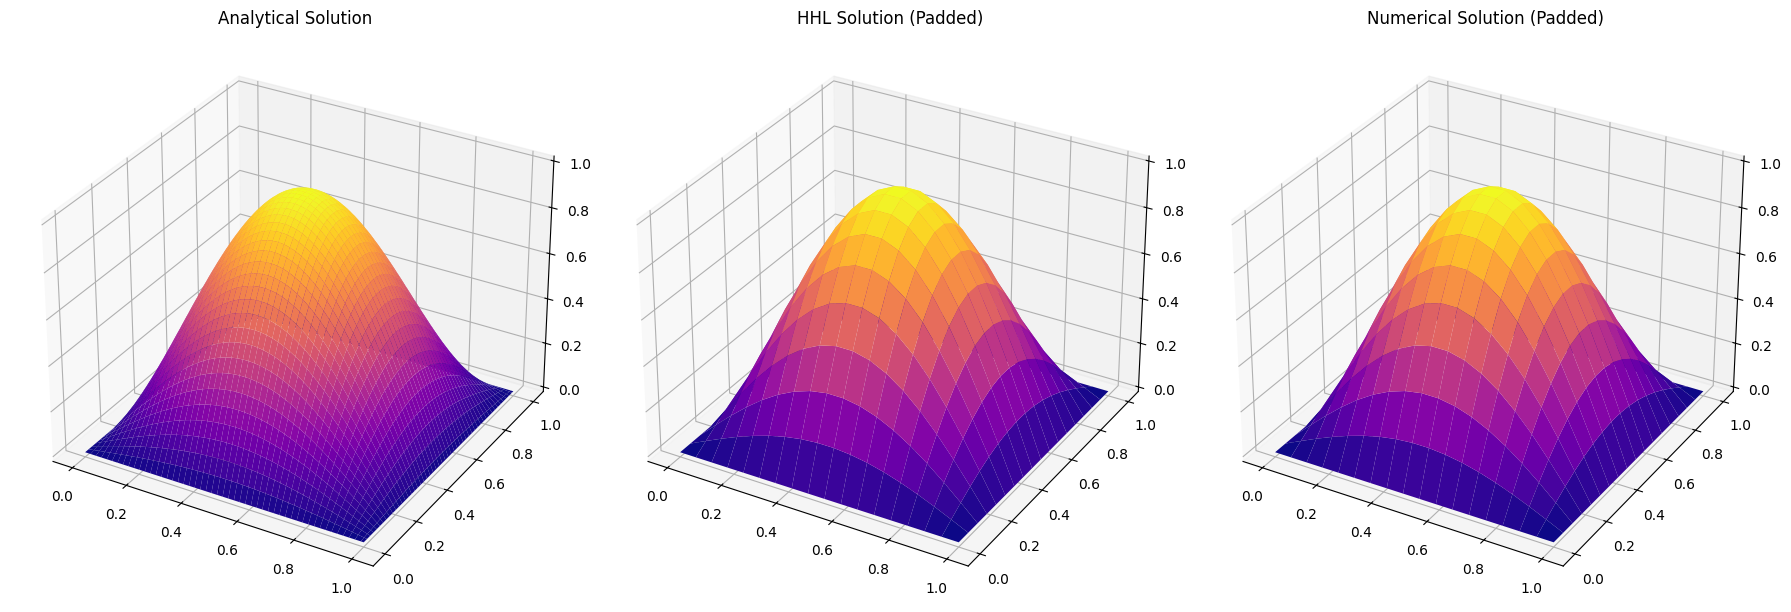

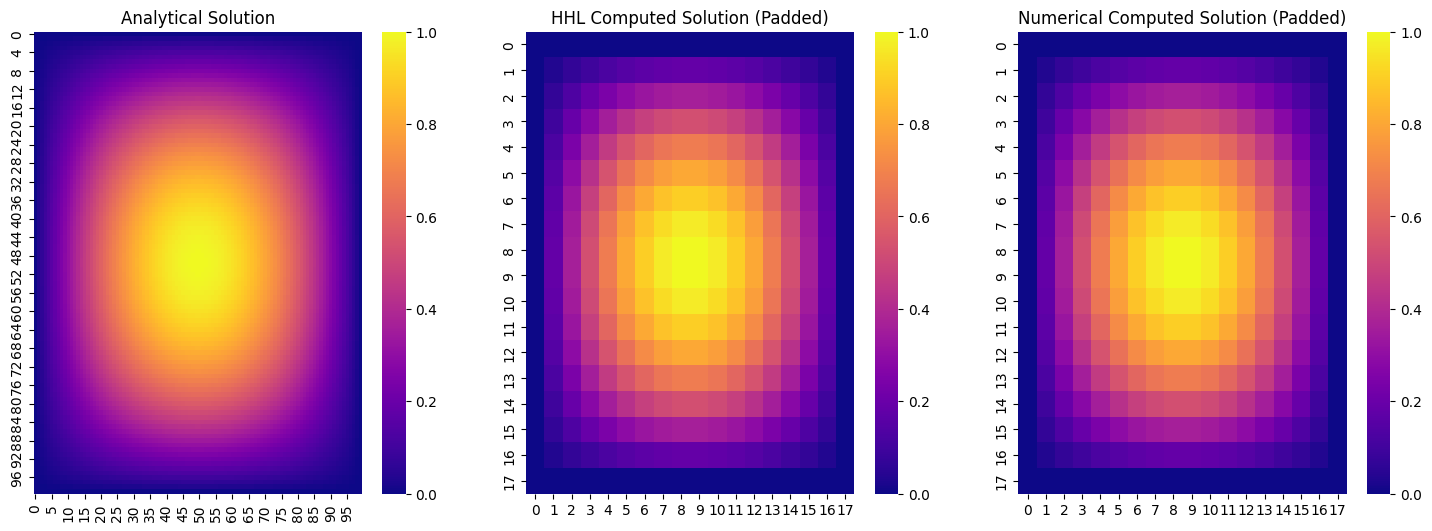

In [107]:
# Plot the error convergence
from matplotlib.pylab import norm, normal

####################################### Final solution #########################################################################
# Pad the computed solution with a boundary of zeros (Dirichlet condition)
u_tom_padded = np.pad(u_tom, pad_width=1, mode='constant', constant_values=0)
u_tom_padded = normalize(u_tom_padded, lb, ub)

u_analytical = normalize(u_analytical, lb, ub)
u_analytical_resampled = normalize(u_analytical_resampled, lb, ub)

u_hhl_padded = np.pad(u_hhl, pad_width=1, mode='constant', constant_values=0)
u_hhl_padded = normalize(u_hhl_padded, lb, ub)

error_hhl_grid = np.abs(u_hhl_padded - u_analytical_resampled)
error_tom_grid = np.abs(u_tom_padded - u_analytical_resampled)

####################################### Final solution #########################################################################
# subplots of the erros heatmap
plt.figure(figsize=(10, 6))
plt.yscale('log')
plt.plot(errors_hhl, 'o-', label='HHL Method')
plt.plot(errors_tom, 's-', label='Thomas Method')
plt.xlabel('Iteration')
plt.ylabel('L2 Error')
plt.title('Error Convergence')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Error Heatmap (HHL)')
sns.heatmap(error_hhl_grid, cmap='coolwarm', cbar=True)
plt.subplot(1, 2, 2)
plt.title('Error Heatmap (Thomas)')
sns.heatmap(error_tom_grid, cmap='coolwarm', cbar=True)
plt.tight_layout()
plt.show()


# plot the 3D surface plots of the solutions side by side using the padded computed solution
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(131, projection='3d')
ax1.set_title('Analytical Solution')
ax1.plot_surface(X_high_res, Y_high_res, u_analytical, cmap='plasma')
ax2 = fig.add_subplot(132, projection='3d')
ax2.set_title('HHL Solution (Padded)')
ax2.plot_surface(x, y, u_hhl_padded, cmap='plasma')
ax3 = fig.add_subplot(133, projection='3d')
ax3.set_title('Numerical Solution (Padded)')
ax3.plot_surface(x, y, u_tom_padded, cmap='plasma')
plt.tight_layout()
plt.show()

# plot the contour plot of the computed solution side by side using the padded computed solution
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.title('Analytical Solution')
sns.heatmap(u_analytical, cmap='plasma')
plt.subplot(1, 3, 2)
plt.title('HHL Computed Solution (Padded)')
sns.heatmap(u_hhl_padded, cmap='plasma')
plt.subplot(1, 3, 3)
plt.title('Numerical Computed Solution (Padded)')
sns.heatmap(u_tom_padded, cmap='plasma')
plt.show()



## Solution Testing :: GAUSS

Define solution and ADI parameters

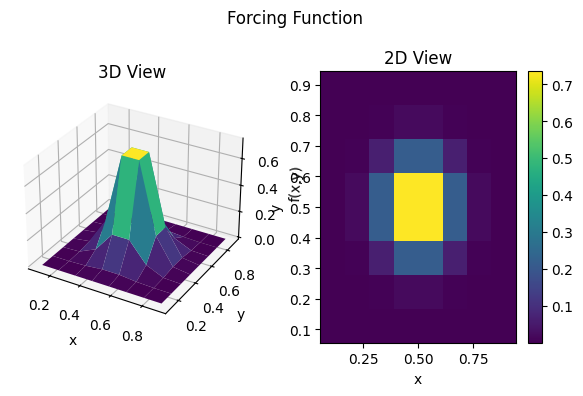

In [ ]:
# Domain specifications
Lx = 1.0       # Length of the x-dimension
Ly = 1.0       # Length of the y-dimension
NUM_QUBITS = 3 # Number of qubits used to represent the solution
N = 2**NUM_QUBITS  # Number of interior grid points in each dimension
N_total = N + 2    # Total grid points including boundaries

dx = Lx / (N + 1)  # Grid spacing (consistent with N interior points)
dy = Ly / (N + 1)

# Create full grid including boundaries
x_vals = np.linspace(0, Lx, N_total)
y_vals = np.linspace(0, Ly, N_total)

# Extract interior points (excluding boundaries)
interior_x = x_vals[1:-1]
interior_y = y_vals[1:-1]
interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

# PDE specifications
k = 2.0  # Wave Number
main_diag = -4/h**2 + k**2  # main diagonal
off_diag = 1/h**2   # off diagonal
Ax = construct_TT_matrix(main_diag=main_diag, off_diag=off_diag, size=N)
Ay = Ax

# Build the forcing function
f, f_grid, x_grid, y_grid = generate_forcing_function(N, N, Lx, Ly, forcing_type='gaussian', x0=Lx/2, y0=Ly/2, sigma=0.1, amplitude=1.0)
# Visualise forcing function
plot_forcing_function(f_grid, x_grid, y_grid, title="Forcing Function")


Call the ADI now

In [ ]:
u_init = np.zeros((N,N))
# Solve using the ADI now in quantum
u_hhl = ADI(u_init , Ax, Ay, f_grid, method='q')

u_tom = ADI(u_init , Ax, Ay, f_grid, method='num')


Iteration: 0
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Num

In [ ]:
# Define higher resolution parameters
N_high_res = 100  # Higher resolution grid size
dx_high_res = Lx / (N_high_res + 1)
dy_high_res = Ly / (N_high_res + 1)
h_high_res = dx_high_res

# Reconstruct the operator matrices for higher resolution
main_diag_high_res = -4 / h_high_res**2 + k**2
off_diag_high_res = 1 / h_high_res**2
Ax_high_res = construct_TT_matrix(main_diag=main_diag_high_res, off_diag=off_diag_high_res, size=N_high_res)
Ay_high_res = Ax_high_res

# Generate the forcing function for higher resolution
_, f_high_res_grid, _, _ = generate_forcing_function(
    N_high_res, N_high_res, Lx, Ly, forcing_type='gaussian', x0=Lx/2, y0=Ly/2, sigma=0.1, amplitude=1.0
)

# Initialize the solution for higher resolution
u_init_high_res = np.zeros((N_high_res, N_high_res))

# Solve using the ADI method with the Thomas algorithm
u_high_res_tom = ADI(u_init_high_res, Ax_high_res, Ay_high_res, f_high_res_grid, method='num')

# Generate the high-resolution grid for visualization
X_high_res, Y_high_res = np.meshgrid(np.linspace(0, Lx, N_high_res + 2), np.linspace(0, Ly, N_high_res + 2), indexing='ij')
u_analytic_high_res = np.pad(u_high_res_tom, pad_width=1, mode='constant', constant_values=0)


Iteration: 0
Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (100, 100) and arg 2 with shape (102, 102).

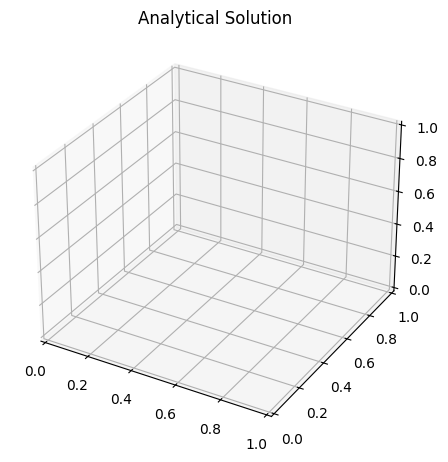

In [108]:
####################################### Final solution #########################################################################
# Pad the computed solution with a boundary of zeros (Dirichlet condition)
x, y = np.meshgrid(x_vals, y_vals, indexing='ij')
u_tom_padded = np.pad(u_tom, pad_width=1, mode='constant', constant_values=0)
u_tom_padded = normalize(u_tom_padded, lb, ub)

u_hhl_padded = np.pad(u_hhl, pad_width=1, mode='constant', constant_values=0)
u_hhl_padded = normalize(u_hhl_padded, lb, ub)

####################################### Final solution #########################################################################
# subplots of the erros heatmap

# plot the 3D surface plots of the solutions side by side using the padded computed solution
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(131, projection='3d')
ax1.set_title('Analytical Solution')
ax1.plot_surface(X_high_res, Y_high_res, u_analytic_high_res, cmap='plasma')
ax2 = fig.add_subplot(132, projection='3d')
ax2.set_title('HHL Solution (Padded)')
ax2.plot_surface(x, y, u_hhl_padded, cmap='plasma')
ax3 = fig.add_subplot(133, projection='3d')
ax3.set_title('Numerical Solution (Padded)')
ax3.plot_surface(x, y, u_tom_padded, cmap='plasma')
plt.tight_layout()
plt.show()

# plot the contour plot of the computed solution side by side using the padded computed solution
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.title('Analytical Solution')
sns.heatmap(u_analytic_high_res, cmap='plasma')
plt.subplot(1, 3, 2)
plt.title('HHL Computed Solution (Padded)')
sns.heatmap(u_hhl_padded, cmap='plasma')
plt.subplot(1, 3, 3)
plt.title('Numerical Computed Solution (Padded)')
sns.heatmap(u_tom_padded, cmap='plasma')
plt.show()


## Solution Testing :: UNIF

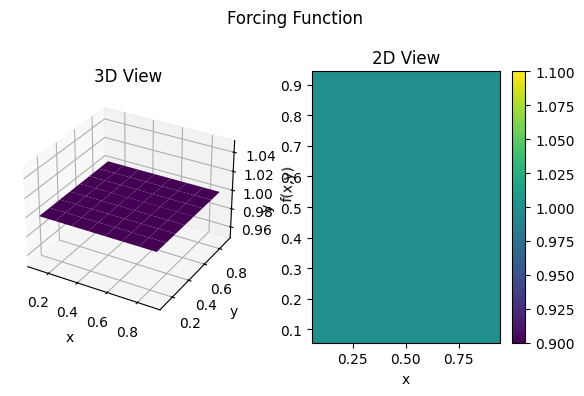

In [95]:
# Domain specifications
Lx = 1.0       # Length of the x-dimension
Ly = 1.0       # Length of the y-dimension
NUM_QUBITS = 3 # Number of qubits used to represent the solution
N = 2**NUM_QUBITS  # Number of interior grid points in each dimension
N_total = N + 2    # Total grid points including boundaries

dx = Lx / (N + 1)  # Grid spacing (consistent with N interior points)
dy = Ly / (N + 1)

# Create full grid including boundaries
x_vals = np.linspace(0, Lx, N_total)
y_vals = np.linspace(0, Ly, N_total)

# Extract interior points (excluding boundaries)
interior_x = x_vals[1:-1]
interior_y = y_vals[1:-1]
interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

# PDE specifications
k = 2.0  # Wave Number
main_diag = -4/h**2 + k**2  # main diagonal
off_diag = 1/h**2   # off diagonal
Ax = construct_TT_matrix(main_diag=main_diag, off_diag=off_diag, size=N)
Ay = Ax

# Build the forcing function
f, f_grid, x_grid, y_grid = generate_forcing_function(N, N, Lx, Ly, forcing_type='uniform', value=1.0)
# Visualise forcing function
plot_forcing_function(f_grid, x_grid, y_grid, title="Forcing Function")


In [96]:
u_init = np.zeros((N,N))
# Solve using the ADI now in quantum
u_hhl = ADI(u_init , Ax, Ay, f_grid, method='q')
u_tom = ADI(u_init , Ax, Ay, f_grid, method='num')

Iteration: 0
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Num

In [97]:
# Define higher resolution parameters
N_high_res = 100  # Higher resolution grid size
dx_high_res = Lx / (N_high_res + 1)
dy_high_res = Ly / (N_high_res + 1)
h_high_res = dx_high_res

# Reconstruct the operator matrices for higher resolution
main_diag_high_res = -4 / h_high_res**2 + k**2
off_diag_high_res = 1 / h_high_res**2
Ax_high_res = construct_TT_matrix(main_diag=main_diag_high_res, off_diag=off_diag_high_res, size=N_high_res)
Ay_high_res = Ax_high_res

# Generate the forcing function for higher resolution
_, f_high_res_grid, _, _ = generate_forcing_function(
    N_high_res, N_high_res, Lx, Ly, forcing_type='uniform', value=1.0
)

# Initialize the solution for higher resolution
u_init_high_res = np.zeros((N_high_res, N_high_res))

# Solve using the ADI method with the Thomas algorithm
u_high_res_tom = ADI(u_init_high_res, Ax_high_res, Ay_high_res, f_high_res_grid, method='num')

# Generate the high-resolution grid for visualization
X_high_res, Y_high_res = np.meshgrid(np.linspace(0, Lx, N_high_res + 2), np.linspace(0, Ly, N_high_res + 2), indexing='ij')
u_analytic_high_res = np.pad(u_high_res_tom, pad_width=1, mode='constant', constant_values=0)


Iteration: 0
Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4


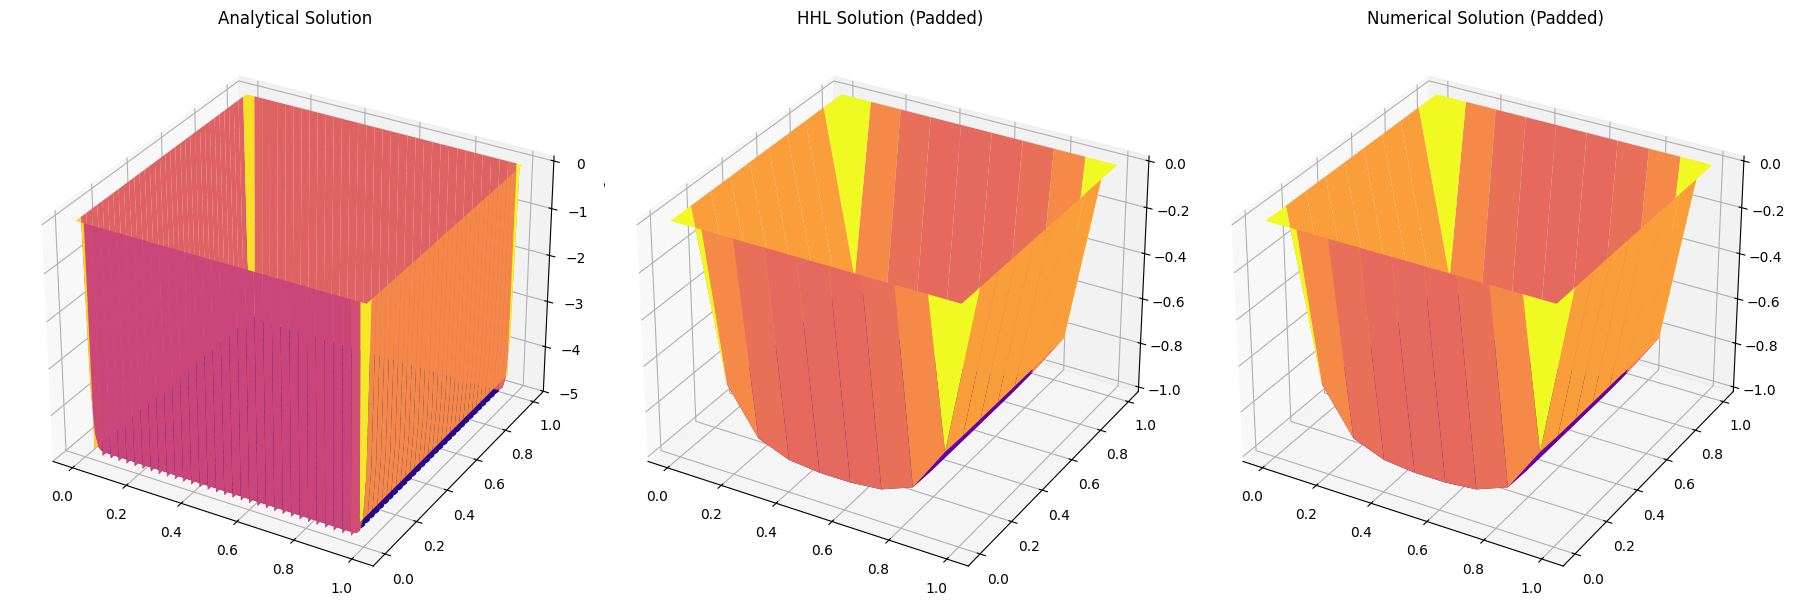

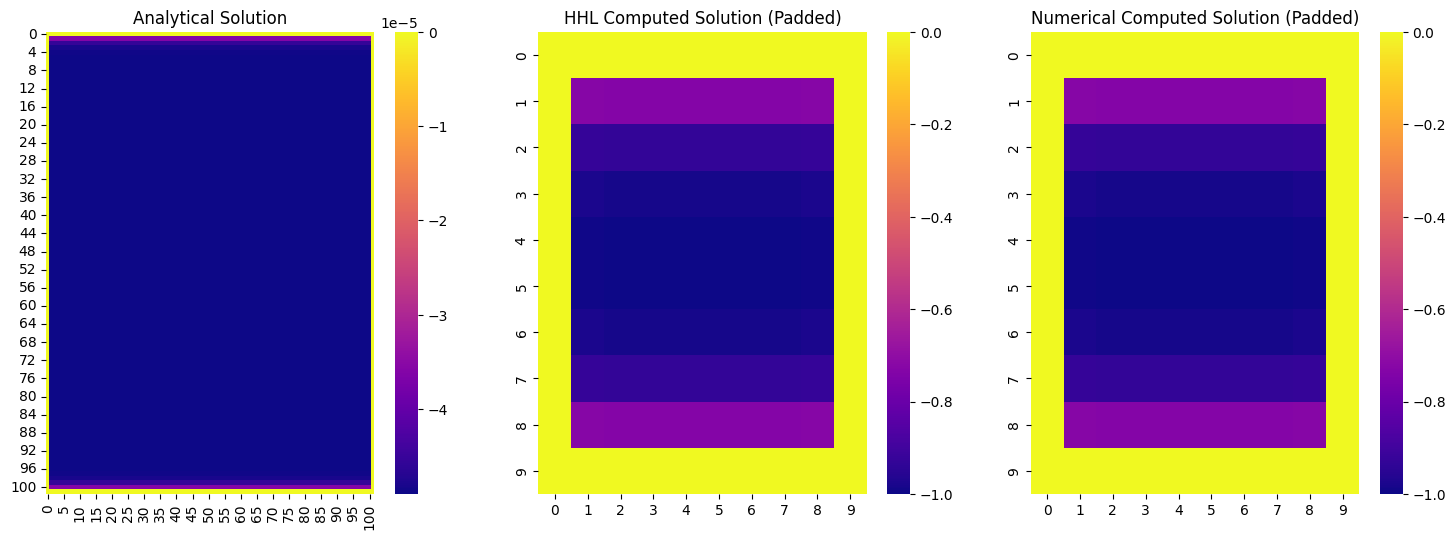

In [98]:
####################################### Final solution #########################################################################
# Pad the computed solution with a boundary of zeros (Dirichlet condition)
x, y = np.meshgrid(x_vals, y_vals, indexing='ij')
u_tom_padded = np.pad(u_tom, pad_width=1, mode='constant', constant_values=0)
u_tom_padded = normalize(u_tom_padded, lb, ub)

u_hhl_padded = np.pad(u_hhl, pad_width=1, mode='constant', constant_values=0)
u_hhl_padded = normalize(u_hhl_padded, lb, ub)

####################################### Final solution #########################################################################
# subplots of the erros heatmap

# plot the 3D surface plots of the solutions side by side using the padded computed solution
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(131, projection='3d')
ax1.set_title('Analytical Solution')
ax1.plot_surface(X_high_res, Y_high_res, u_analytic_high_res, cmap='plasma')
ax2 = fig.add_subplot(132, projection='3d')
ax2.set_title('HHL Solution (Padded)')
ax2.plot_surface(x, y, u_hhl_padded, cmap='plasma')
ax3 = fig.add_subplot(133, projection='3d')
ax3.set_title('Numerical Solution (Padded)')
ax3.plot_surface(x, y, u_tom_padded, cmap='plasma')
plt.tight_layout()
plt.show()

# plot the contour plot of the computed solution side by side using the padded computed solution
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.title('Analytical Solution')
sns.heatmap(u_analytic_high_res, cmap='plasma')
plt.subplot(1, 3, 2)
plt.title('HHL Computed Solution (Padded)')
sns.heatmap(u_hhl_padded, cmap='plasma')
plt.subplot(1, 3, 3)
plt.title('Numerical Computed Solution (Padded)')
sns.heatmap(u_tom_padded, cmap='plasma')
plt.show()